# Notebook 03 — The Central Dogma: DNA → RNA → Protein

**Module:** 05 — Biology Fundamentals  
**Notebook:** 03 of 18  
**Prerequisites:** NB02  
**Time estimate:** 90 minutes

> **Track A critical.** 'Explain what RNA-seq measures' is a common opening interview
> question. The correct answer requires knowing this notebook thoroughly.

---
## Step 1 — Motivation

RNA-seq, ChIP-seq, Ribo-seq, proteomics — every major genomics technology measures
one step in the DNA → RNA → protein pipeline. Without understanding this pipeline,
you cannot interpret what these experiments actually measure, why they measure it,
or what biological question each one answers.

---
## Step 2 — Intuition: The Central Dogma as a Data Pipeline

```
DNA  ────[transcription]────►  mRNA  ────[translation]────►  Protein
 │                              │                              │
Source code                  Runtime                       Executable
(stored, heritable)          (temporary, cell-specific)   (does the work)
```

What each assay measures:
- **WGS/WES:** reads the source code (DNA sequence)
- **ATAC-seq/ChIP-seq:** reads which parts of the source code are accessible or bound
- **RNA-seq:** counts which mRNAs (runtime) are active
- **Ribo-seq:** counts which mRNAs are actively being translated
- **Proteomics (mass spec):** counts which proteins (executables) are present

---
## Step 3 — Biological Background

### DNA Structure
- Double helix: two complementary antiparallel strands
- Base pairs: Adenine (A) pairs with Thymine (T) via 2 hydrogen bonds;
  Cytosine (C) pairs with Guanine (G) via 3 hydrogen bonds
- Strands run 5'→3' in opposite directions (antiparallel)
- Strand 1: 5'-ATGCGATC-3'; Strand 2: 3'-TACGCTAG-5'

### Transcription (DNA → mRNA)
- RNA polymerase reads the template strand 3'→5' and synthesises mRNA 5'→3'
- In eukaryotes: **pre-mRNA** is first produced (includes introns)
- **Splicing** removes introns; exons are joined → mature mRNA
- 5' cap and poly-A tail added for stability and nuclear export
- mRNA is exported to the cytoplasm for translation

### Translation (mRNA → Protein)
- Ribosome reads the mRNA in triplets called **codons** (64 total, 3 are stop codons)
- Each codon specifies one amino acid (the genetic code — nearly universal)
- tRNA molecules bring the correct amino acid to each codon
- **Start codon:** AUG (methionine). **Stop codons:** UAA, UAG, UGA.
- Chain of amino acids = **polypeptide** → folds into functional **protein**

### Why RNA-seq doesn't measure proteins
mRNA abundance ≠ protein abundance. Reasons:
1. mRNA stability varies (some degrade in minutes, others last hours)
2. Translation efficiency varies (same mRNA can produce different amounts of protein)
3. Protein half-life varies (some are quickly degraded)
4. Post-translational modifications change protein function after translation

The correlation between mRNA and protein levels is ~0.4–0.6 in mammalian cells.

---
## Step 4 — Mathematical Explanation

**The genetic code:** 4 nucleotides → 4³ = 64 codons → 20 amino acids + 3 stop codons.
The code is **degenerate**: most amino acids are encoded by 2–6 different codons.

**Codon table structure:** the wobble position (3rd base) is least constrained —
synonymous codons (same amino acid) usually differ only at position 3.

**Complementarity rule:**
- DNA: A↔T, C↔G
- RNA: A↔U, C↔G (uracil replaces thymine in RNA)
- Template strand → mRNA: T→A, A→U, C→G, G→C

**Reading frame:** AUG sets the reading frame. A frameshift mutation (insertion or
deletion of non-multiple-of-3 bases) changes every codon downstream — usually fatal.

---
## Step 6 — Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# Cell 6.1 — Genetic code table and sequence operations from scratch

# Standard genetic code (RNA codons → amino acid single-letter code)
GENETIC_CODE = {
    'UUU': 'F', 'UUC': 'F', 'UUA': 'L', 'UUG': 'L',
    'CUU': 'L', 'CUC': 'L', 'CUA': 'L', 'CUG': 'L',
    'AUU': 'I', 'AUC': 'I', 'AUA': 'I', 'AUG': 'M',  # AUG = START
    'GUU': 'V', 'GUC': 'V', 'GUA': 'V', 'GUG': 'V',
    'UCU': 'S', 'UCC': 'S', 'UCA': 'S', 'UCG': 'S',
    'CCU': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'ACU': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'GCU': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'UAU': 'Y', 'UAC': 'Y', 'UAA': '*', 'UAG': '*',  # * = STOP
    'CAU': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'AAU': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'GAU': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'UGU': 'C', 'UGC': 'C', 'UGA': '*', 'UGG': 'W',  # * = STOP
    'CGU': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'AGU': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GGU': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G',
}

def dna_to_mrna(dna_template: str) -> str:
    """Transcribe DNA template strand (3'→5') to mRNA (5'→3')."""
    complement = {'A': 'U', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in dna_template)

def translate(mrna: str) -> str:
    """
    Translate mRNA to protein starting from first AUG.
    Returns protein sequence up to and excluding stop codon.
    """
    start = mrna.find('AUG')
    if start == -1:
        return ''
    protein = []
    for i in range(start, len(mrna) - 2, 3):
        codon = mrna[i:i+3]
        if len(codon) < 3:
            break
        aa = GENETIC_CODE.get(codon, '?')
        if aa == '*':   # stop codon
            break
        protein.append(aa)
    return ''.join(protein)

# Example: a short synthetic gene
dna_template = 'TACGAAATTTTTCGA'  # template strand 3'→5'
mrna = dna_to_mrna(dna_template)
protein = translate(mrna)

print(f"DNA template (3'→5'): {dna_template}")
print(f"mRNA      (5'→3'): {mrna}")
print(f"Protein:             {protein}")
print()

# Real example: human insulin B-chain begins with FVNQH...
insulin_mrna = 'AUGUUUGUGAACCAGCACCCUGCGGCCGCUGCAGCUCUACC'
print(f"Insulin B-chain mRNA: {insulin_mrna}")
print(f"Translation:          {translate(insulin_mrna)}")

DNA template (3'→5'): TACGAAATTTTTCGA
mRNA      (5'→3'): AUGCUUUAAAAAGCU
Protein:             ML

Insulin B-chain mRNA: AUGUUUGUGAACCAGCACCCUGCGGCCGCUGCAGCUCUACC
Translation:          MFVNQHPAAAAAL


In [3]:
# Cell 6.2 — Genetic code degeneracy: how many codons per amino acid?
from collections import Counter

aa_codon_count = Counter(aa for aa in GENETIC_CODE.values() if aa != '*')
print("Amino acid degeneracy (codons per amino acid):")
for aa, count in sorted(aa_codon_count.items(), key=lambda x: -x[1]):
    print(f"  {aa}: {count} {'█' * count}")
print(f"\n20 amino acids, {sum(aa_codon_count.values())} sense codons, 3 stop codons = 64 total")

Amino acid degeneracy (codons per amino acid):
  L: 6 ██████
  S: 6 ██████
  R: 6 ██████
  V: 4 ████
  P: 4 ████
  T: 4 ████
  A: 4 ████
  G: 4 ████
  I: 3 ███
  F: 2 ██
  Y: 2 ██
  H: 2 ██
  Q: 2 ██
  N: 2 ██
  K: 2 ██
  D: 2 ██
  E: 2 ██
  C: 2 ██
  M: 1 █
  W: 1 █

20 amino acids, 61 sense codons, 3 stop codons = 64 total


In [4]:
# Cell 6.3 — Frameshift mutation: why non-3n indels are devastating
original_mrna = 'AUGCCGAAUUGGAAAGCUUGA'  # AUG CCG AAU UGG AAA GCU UGA
# Insert one extra base after position 3 → frameshift
frameshift = original_mrna[:3] + 'A' + original_mrna[3:]

print(f"Original mRNA:   {original_mrna}")
print(f"Protein:         {translate(original_mrna)}")
print()
print(f"Frameshift mRNA: {frameshift}")
print(f"Protein:         {translate(frameshift)}  ← completely different!")

Original mRNA:   AUGCCGAAUUGGAAAGCUUGA
Protein:         MPNWKA

Frameshift mRNA: AUGACCGAAUUGGAAAGCUUGA
Protein:         MTELESL  ← completely different!


---
## Step 7 — Visualization

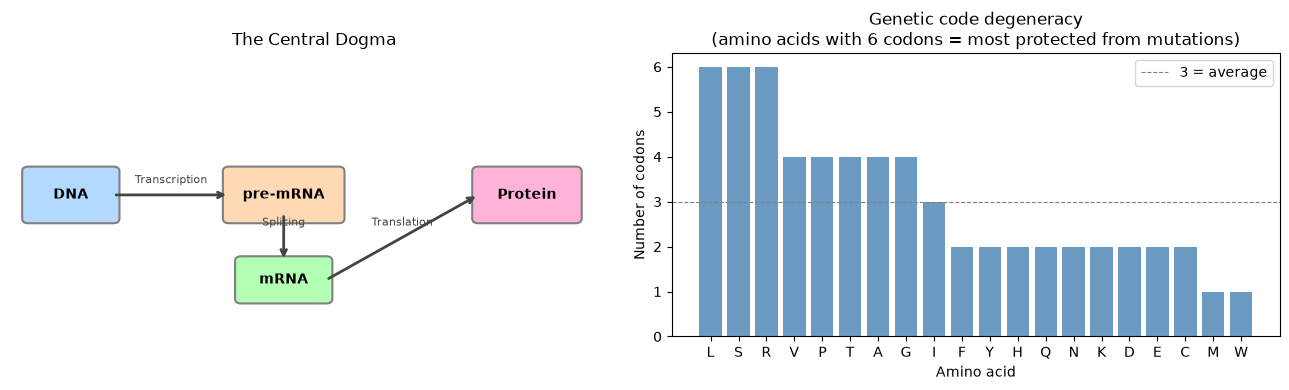

In [5]:
# Cell 7.1 — Central dogma flow diagram + codon degeneracy histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: Central dogma flow diagram
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
boxes = [
    (1, 3, 'DNA', '#b3d9ff', 1.4, 1.0),
    (4.5, 3, 'pre-mRNA', '#ffd9b3', 1.8, 1.0),
    (4.5, 1.2, 'mRNA', '#b3ffb3', 1.4, 0.8),
    (8.5, 3, 'Protein', '#ffb3d9', 1.6, 1.0),
]
for (x, y, label, color, w, h) in boxes:
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle='round,pad=0.1', facecolor=color, edgecolor='gray', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontweight='bold', fontsize=10)

arrows = [
    (1.7, 3.0, 3.6, 3.0, 'Transcription'),
    (4.5, 2.6, 4.5, 1.6, 'Splicing'),
    (5.2, 1.2, 7.7, 3.0, 'Translation'),
]
for (x1, y1, x2, y2, label) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=2))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my + 0.25, label, ha='center', fontsize=8, color='#444')

ax.set_title('The Central Dogma', fontsize=12)

# Panel 2: Codon degeneracy
ax = axes[1]
aas_sorted = sorted(aa_codon_count.items(), key=lambda x: -x[1])
aa_labels, counts = zip(*aas_sorted)
ax.bar(aa_labels, counts, color='steelblue', alpha=0.8)
ax.set_xlabel('Amino acid'); ax.set_ylabel('Number of codons')
ax.set_title('Genetic code degeneracy\n(amino acids with 6 codons = most protected from mutations)')
ax.axhline(3, color='gray', ls='--', lw=0.8, label='3 = average')
ax.legend()

plt.tight_layout()
plt.show()

---
## Step 8 — Exercises

1. Implement `dna_to_mrna()` from scratch without looking at the code. Test it on
   `'TACGAAATTTTTCGA'`. Verify you get `'AUGCUUUAAAAGCU'`.
2. Implement `translate()` from scratch. What happens if the mRNA has no AUG?
   What happens if it has AUG but no stop codon?
3. A gene has a nonsense mutation: a point mutation changes a codon to a stop codon.
   A gene has a missense mutation: a point mutation changes a codon to a different
   amino acid codon. Which is more damaging? Why might a synonymous mutation
   (same amino acid) still be harmful?
4. RNA-seq measures mRNA abundance. Name two biological processes that would cause
   mRNA abundance to be *high* without a corresponding increase in protein.

---
## Quiz — Active Recall (Track A critical)

1. What is the central dogma of molecular biology? State it in one sentence.
2. What is the difference between transcription and translation? Where does each happen?
3. What is a codon? How many codons are there? How many code for amino acids?
4. What is a frameshift mutation? Why is it usually more harmful than a point mutation?
5. Why does RNA-seq not directly measure protein levels?

---
## Papers Referenced

- Watson & Crick (1953). DOI: 10.1038/171737a0

---
## Reflection

**Date completed:** ____________________

> *[Can you explain what RNA-seq measures and why, in 30 seconds, without notes?]*

---
*Next: `04_chromosomes_genes_genome_scale.ipynb`*